
# Actividad 02 - Algoritmos Genéticos en Machine Learning
## Integrante 2 - Feature Selection

### Objetivo del ejemplo
Usar un **algoritmo genético (AG)** para encontrar un subconjunto de características que permita clasificar los datos con buen rendimiento usando menos variables.

### Dataset
Se usa **Breast Cancer Wisconsin (Diagnostic)** de `scikit-learn`.

- 569 registros.
- 30 características numéricas originales.
- 2 clases.
- No requiere One-Hot Encoding.

### Modelo de ML
**Regresión Logística** con `StandardScaler`.

### ¿Qué optimiza el algoritmo genético?
El AG **no modifica el modelo**. Evoluciona una máscara binaria de 30 posiciones que indica qué columnas usar.

`1 = usar la característica`  
`0 = descartar la característica`

Ejemplo conceptual:

`[1, 0, 1, 1, 0, ...]`

Cada vector binario es un **cromosoma o individuo**.



## Ciclo genético que debemos identificar en el código

**Población inicial → Fitness → Selección → Cruzamiento → Mutación → Nueva población → Terminación**

En este notebook se implementan explícitamente las seis partes para que puedan señalarse durante la exposición.


In [1]:

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



## 1. Cargar y revisar el dataset

Esta celda permite demostrar que el conjunto de datos cumple la recomendación de tener **más de 10 características originales**. Aquí existen 30 y todas son numéricas, por lo que no se crean columnas mediante One-Hot Encoding.


In [2]:

data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

print("Dimensión de X:", X.shape)
print("Número de registros:", X.shape[0])
print("Número de características:", X.shape[1])
print("Clases:", list(data.target_names))
print("\nPrimeras 5 características:")
print(list(X.columns[:5]))

X.head()


Dimensión de X: (569, 30)
Número de registros: 569
Número de características: 30
Clases: [np.str_('malignant'), np.str_('benign')]

Primeras 5 características:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



## 2. Separación entrenamiento / prueba

El **80 %** se utiliza para entrenar y para calcular el fitness mediante validación cruzada.

El **20 % de test queda aislado** hasta el final. Esto evita que el algoritmo genético "aprenda" indirectamente del conjunto con el que luego evaluaremos el resultado.


In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

N_FEATURES = X.shape[1]

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

def crear_modelo():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            random_state=SEED
        ))
    ])

print("Train:", X_train.shape)
print("Test: ", X_test.shape)


Train: (455, 30)
Test:  (114, 30)



## 3. Modelo base

Antes de hacer Feature Selection necesitamos una referencia.

Entrenamos el mismo modelo utilizando las **30 características**. Luego podremos comparar contra la solución encontrada por el algoritmo genético.


In [4]:

baseline_cv_scores = cross_val_score(
    crear_modelo(),
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

baseline_cv = baseline_cv_scores.mean()

baseline_model = crear_modelo()
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_test = accuracy_score(y_test, baseline_pred)

print(f"Características: {N_FEATURES}")
print(f"Accuracy promedio CV: {baseline_cv:.4f}")
print(f"Accuracy test:        {baseline_test:.4f}")


Características: 30
Accuracy promedio CV: 0.9802
Accuracy test:        0.9825



# Algoritmo Genético

## 4. Parámetros

Para la demostración usamos una población pequeña para que pueda ejecutarse rápidamente durante la exposición.

- **Población:** 20 individuos.
- **Generaciones:** 12.
- **Selección:** torneo de 3 individuos.
- **Crossover:** 90 %.
- **Mutación:** `1 / número_de_features`, aproximadamente 3.33 % por gen.
- **Elitismo:** se conservan los 2 mejores individuos.


In [5]:

POP_SIZE = 20
N_GENERATIONS = 12
TOURNAMENT_SIZE = 3
CROSSOVER_RATE = 0.90
MUTATION_RATE = 1 / N_FEATURES
ELITE_SIZE = 2
PENALTY = 0.01

print("Tamaño de población:", POP_SIZE)
print("Generaciones:", N_GENERATIONS)
print(f"Probabilidad de mutación por gen: {MUTATION_RATE:.4f}")


Tamaño de población: 20
Generaciones: 12
Probabilidad de mutación por gen: 0.0333



## 5. Representación e inicialización

Un individuo es un vector binario de longitud 30.

Ejemplo:

`[1, 0, 1, 0, ...]`

- `1`: la característica participa en el entrenamiento.
- `0`: la característica se descarta.

La población inicial se crea aleatoriamente. Se evita el caso de un cromosoma completamente en cero.


In [6]:

def crear_individuo():
    individuo = np.random.randint(0, 2, size=N_FEATURES, dtype=int)

    if individuo.sum() == 0:
        individuo[np.random.randint(N_FEATURES)] = 1

    return individuo

ejemplo = crear_individuo()

print("Ejemplo de cromosoma:")
print(ejemplo)
print("Características activas:", ejemplo.sum())


Ejemplo de cromosoma:
[0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1]
Características activas: 16



## 6. Función de aptitud (Fitness)

El fitness debe indicar qué tan buena es una solución.

En este ejemplo:

\[
Fitness = Accuracy_{CV} - 0.01\left(\frac{Nº\ características\ seleccionadas}{30}\right)
\]

La primera parte premia una buena clasificación.  
La segunda aplica una **penalización pequeña** a los individuos que usan demasiadas columnas.

De esta manera buscamos un equilibrio:

> **buen rendimiento + menor cantidad de características**

El conjunto de test **no participa** en el fitness.


In [7]:

def evaluar_fitness(individuo):
    mascara = individuo.astype(bool)
    cantidad = int(mascara.sum())

    if cantidad == 0:
        return -1.0, 0.0

    X_seleccionado = X_train.iloc[:, mascara]

    accuracy_cv = cross_val_score(
        crear_modelo(),
        X_seleccionado,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    fitness = accuracy_cv - PENALTY * (cantidad / N_FEATURES)

    return float(fitness), float(accuracy_cv)

fitness_ejemplo, accuracy_ejemplo = evaluar_fitness(ejemplo)

print(f"Fitness del individuo: {fitness_ejemplo:.4f}")
print(f"Accuracy CV:            {accuracy_ejemplo:.4f}")


Fitness del individuo: 0.9727
Accuracy CV:            0.9780



## 7. Selección por torneo

Se escogen **3 individuos al azar** de la población.

El individuo con mejor fitness gana el torneo y puede convertirse en padre de la siguiente generación.

Esto favorece a las soluciones buenas sin impedir completamente que otros individuos participen.


In [8]:

def seleccion_torneo(poblacion, fitnesses):
    candidatos = np.random.choice(
        len(poblacion),
        size=TOURNAMENT_SIZE,
        replace=False
    )

    ganador = max(candidatos, key=lambda i: fitnesses[i][0])

    return poblacion[ganador].copy()



## 8. Cruzamiento uniforme

Se combinan dos padres.

Para cada posición del cromosoma decidimos aleatoriamente de cuál padre heredar el gen.

Conceptualmente:

Padre 1: `1 0 1 1 0`  
Padre 2: `0 1 1 0 1`  
Hijo:    `1 1 1 0 0`


In [9]:

def cruzamiento_uniforme(padre1, padre2):
    if np.random.rand() > CROSSOVER_RATE:
        return padre1.copy(), padre2.copy()

    mascara = np.random.rand(N_FEATURES) < 0.5

    hijo1 = np.where(mascara, padre1, padre2).astype(int)
    hijo2 = np.where(mascara, padre2, padre1).astype(int)

    if hijo1.sum() == 0:
        hijo1[np.random.randint(N_FEATURES)] = 1

    if hijo2.sum() == 0:
        hijo2[np.random.randint(N_FEATURES)] = 1

    return hijo1, hijo2



## 9. Mutación

Después del crossover, cada gen tiene una pequeña probabilidad de cambiar.

`0 → 1` o `1 → 0`

La mutación mantiene diversidad en la población y ayuda a explorar soluciones que podrían no aparecer únicamente combinando los padres.


In [10]:

def mutacion(individuo):
    hijo = individuo.copy()

    genes_a_mutar = np.random.rand(N_FEATURES) < MUTATION_RATE
    hijo[genes_a_mutar] = 1 - hijo[genes_a_mutar]

    if hijo.sum() == 0:
        hijo[np.random.randint(N_FEATURES)] = 1

    return hijo



## 10. Evolución

Ahora juntamos todo:

1. Inicialización.
2. Fitness.
3. Selección.
4. Cruzamiento.
5. Mutación.
6. Reemplazo de la población.
7. Repetición durante 12 generaciones.

También utilizamos **elitismo**: los dos mejores individuos pasan directamente a la nueva generación.


In [11]:

np.random.seed(SEED)
random.seed(SEED)

poblacion = [crear_individuo() for _ in range(POP_SIZE)]

historial = []
mejor_global = None
mejor_fitness_global = -np.inf
mejor_accuracy_cv_global = 0.0

for generacion in range(1, N_GENERATIONS + 1):

    # A) Evaluación de toda la población
    fitnesses = [evaluar_fitness(ind) for ind in poblacion]

    # B) Ordenar de mejor a peor
    orden = sorted(
        range(POP_SIZE),
        key=lambda i: fitnesses[i][0],
        reverse=True
    )

    mejor_idx = orden[0]
    mejor_individuo_gen = poblacion[mejor_idx]
    mejor_fitness_gen, mejor_accuracy_gen = fitnesses[mejor_idx]

    # C) Guardar mejor solución global
    if mejor_fitness_gen > mejor_fitness_global:
        mejor_fitness_global = mejor_fitness_gen
        mejor_accuracy_cv_global = mejor_accuracy_gen
        mejor_global = mejor_individuo_gen.copy()

    historial.append({
        "generacion": generacion,
        "mejor_fitness": mejor_fitness_gen,
        "mejor_accuracy_cv": mejor_accuracy_gen,
        "caracteristicas": int(mejor_individuo_gen.sum()),
        "fitness_promedio": float(np.mean([f[0] for f in fitnesses]))
    })

    print(
        f"Generación {generacion:02d} | "
        f"fitness={mejor_fitness_gen:.4f} | "
        f"accuracy_cv={mejor_accuracy_gen:.4f} | "
        f"features={int(mejor_individuo_gen.sum()):02d}"
    )

    # D) Elitismo
    nueva_poblacion = [
        poblacion[i].copy()
        for i in orden[:ELITE_SIZE]
    ]

    # E) Crear descendencia
    while len(nueva_poblacion) < POP_SIZE:
        padre1 = seleccion_torneo(poblacion, fitnesses)
        padre2 = seleccion_torneo(poblacion, fitnesses)

        hijo1, hijo2 = cruzamiento_uniforme(padre1, padre2)

        hijo1 = mutacion(hijo1)
        hijo2 = mutacion(hijo2)

        nueva_poblacion.extend([hijo1, hijo2])

    poblacion = nueva_poblacion[:POP_SIZE]


Generación 01 | fitness=0.9727 | accuracy_cv=0.9780 | features=16


Generación 02 | fitness=0.9752 | accuracy_cv=0.9802 | features=15


Generación 03 | fitness=0.9771 | accuracy_cv=0.9824 | features=16


Generación 04 | fitness=0.9793 | accuracy_cv=0.9846 | features=16


Generación 05 | fitness=0.9793 | accuracy_cv=0.9846 | features=16


...

Generación 08 | fitness=0.9803 | accuracy_cv=0.9846 | features=13


Generación 09 | fitness=0.9815 | accuracy_cv=0.9868 | features=16


Generación 10 | fitness=0.9815 | accuracy_cv=0.9868 | features=16


Generación 11 | fitness=0.9815 | accuracy_cv=0.9868 | features=16


Generación 12 | fitness=0.9815 | accuracy_cv=0.9868 | features=16



## 11. Mejor solución encontrada

El mejor cromosoma se convierte nuevamente en nombres de columnas para saber qué características decidió conservar el algoritmo genético.


In [12]:

mascara_final = mejor_global.astype(bool)
caracteristicas_seleccionadas = X.columns[mascara_final].tolist()

print(f"Fitness final: {mejor_fitness_global:.4f}")
print(f"Accuracy CV: {mejor_accuracy_cv_global:.4f}")
print(f"Características originales: {N_FEATURES}")
print(f"Características seleccionadas: {len(caracteristicas_seleccionadas)}")
print(
    f"Reducción: "
    f"{(1 - len(caracteristicas_seleccionadas)/N_FEATURES)*100:.1f}%"
)

pd.DataFrame({
    "Característica seleccionada": caracteristicas_seleccionadas
})


Fitness final: 0.9815
Accuracy CV: 0.9868
Características originales: 30
Características seleccionadas: 16
Reducción: 46.7%


,Característica seleccionada
0,mean texture
1,mean compactness
2,mean concavity
3,mean concave points
4,mean symmetry
5,area error
6,compactness error
7,concavity error
8,concave points error
9,fractal dimension error



## 12. Evaluación final

Solo ahora utilizamos el conjunto de test.

Entrenamos nuevamente una Regresión Logística empleando únicamente las variables seleccionadas y la comparamos contra el modelo base de 30 características.

**Importante:** no es obligatorio que el subconjunto gane en accuracy de test. Feature Selection busca reducir variables manteniendo un rendimiento competitivo. Si se reducen muchas características con una pérdida pequeña de accuracy, existe un trade-off interpretable entre simplicidad y rendimiento.


In [13]:

modelo_final = crear_modelo()
modelo_final.fit(
    X_train[caracteristicas_seleccionadas],
    y_train
)

pred_final = modelo_final.predict(
    X_test[caracteristicas_seleccionadas]
)

accuracy_final_test = accuracy_score(y_test, pred_final)

resumen = pd.DataFrame({
    "Modelo": ["Base", "Feature Selection con AG"],
    "Features": [N_FEATURES, len(caracteristicas_seleccionadas)],
    "Accuracy test": [baseline_test, accuracy_final_test]
})

resumen


,Modelo,Features,Accuracy test
0,Base,30,0.982456
1,Feature Selection con AG,16,0.973684


In [14]:

print("Matriz de confusión:")
print(confusion_matrix(y_test, pred_final))

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        pred_final,
        target_names=data.target_names,
        digits=4
    )
)


Matriz de confusión:
[[41  1]
 [ 2 70]]

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant     0.9535    0.9762    0.9647        42
      benign     0.9859    0.9722    0.9790        72

    accuracy                         0.9737       114
   macro avg     0.9697    0.9742    0.9719       114
weighted avg     0.9740    0.9737    0.9737       114




# 13. Visualización de la evolución

Estas gráficas son útiles durante la exposición porque permiten mostrar que el algoritmo no probó una sola combinación, sino que **evolucionó una población durante varias generaciones**.


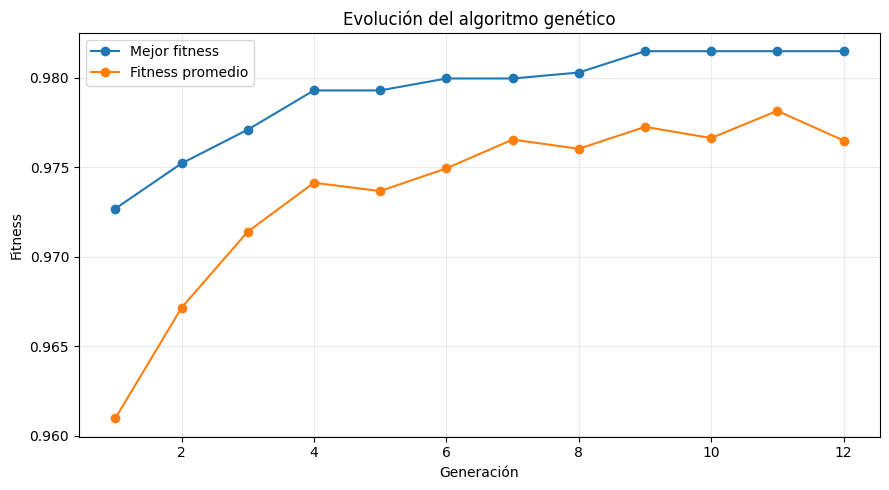

In [15]:

historial_df = pd.DataFrame(historial)

plt.figure(figsize=(9, 5))
plt.plot(
    historial_df["generacion"],
    historial_df["mejor_fitness"],
    marker="o",
    label="Mejor fitness"
)
plt.plot(
    historial_df["generacion"],
    historial_df["fitness_promedio"],
    marker="o",
    label="Fitness promedio"
)
plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.title("Evolución del algoritmo genético")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


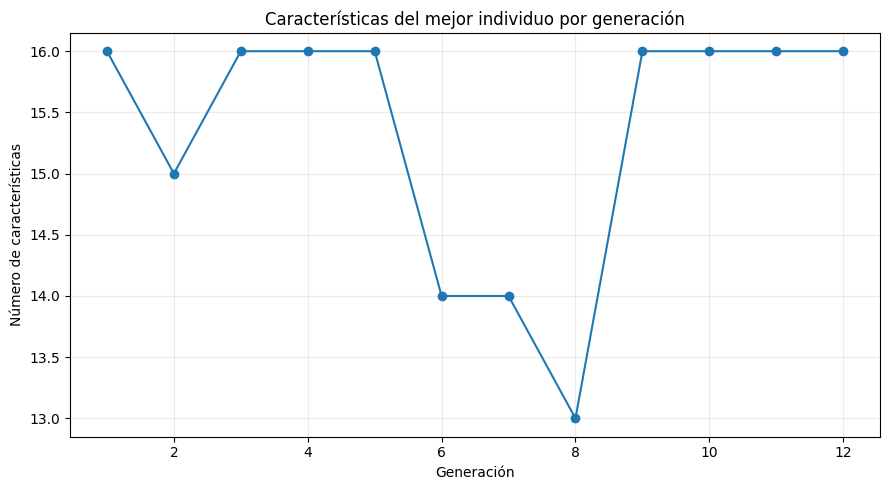

In [16]:

plt.figure(figsize=(9, 5))
plt.plot(
    historial_df["generacion"],
    historial_df["caracteristicas"],
    marker="o"
)
plt.xlabel("Generación")
plt.ylabel("Número de características")
plt.title("Características del mejor individuo por generación")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


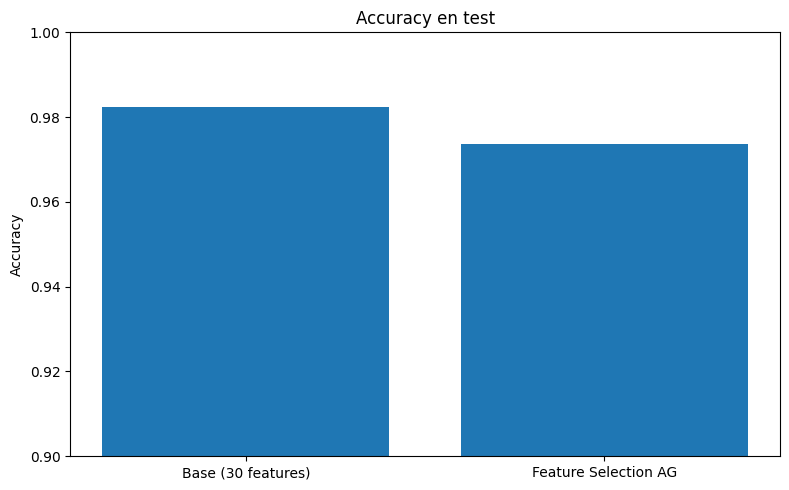

In [17]:

plt.figure(figsize=(8, 5))
plt.bar(
    ["Base (30 features)", "Feature Selection AG"],
    [baseline_test, accuracy_final_test]
)
plt.ylim(0.90, 1.00)
plt.ylabel("Accuracy")
plt.title("Accuracy en test")
plt.tight_layout()
plt.show()


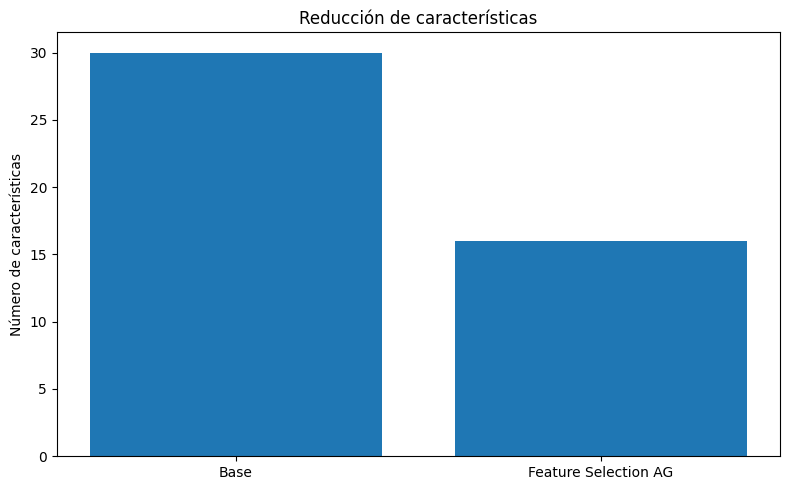

In [18]:

plt.figure(figsize=(8, 5))
plt.bar(
    ["Base", "Feature Selection AG"],
    [N_FEATURES, len(caracteristicas_seleccionadas)]
)
plt.ylabel("Número de características")
plt.title("Reducción de características")
plt.tight_layout()
plt.show()



# Qué debes explicar en la exposición

### 1. Problema
Tenemos 30 variables y queremos encontrar automáticamente un subconjunto útil.

### 2. Cromosoma
Una máscara binaria de 30 posiciones.

`1 = usar`  
`0 = descartar`

### 3. Inicialización
Creamos 20 cromosomas aleatorios.

### 4. Fitness
Medimos el accuracy mediante validación cruzada y aplicamos una pequeña penalización por usar muchas columnas.

### 5. Selección
Torneo de 3 individuos.

### 6. Cruzamiento
Crossover uniforme entre dos padres.

### 7. Mutación
Cada bit puede cambiar con probabilidad aproximada de 3.33 %.

### 8. Terminación
El proceso termina después de 12 generaciones.

### 9. Resultado
Comparamos:
- Modelo base: 30 características.
- Modelo con características seleccionadas por AG.

### Frase final sugerida
> El algoritmo genético convirtió la selección de características en un problema de optimización. Cada cromosoma representa un subconjunto de variables y, generación tras generación, el proceso busca soluciones que mantengan buen rendimiento usando menos información.
